# 03 — Регуляризация Ridge / Lasso / ElasticNet на Advertising

В предыдущей теме мы видели, что polynomial(3) переобучается. Регуляризация — штраф на большие веса в loss-функции — лекарство от этого. Здесь разберём три вида: Ridge (L2), Lasso (L1) и ElasticNet (L1+L2).

## Setup

Что мы будем вызывать впервые:

- `Ridge(alpha=N)` — линрег + L2-штраф (`+ α·Σwᵢ²`).
- `Lasso(alpha=N)` — линрег + L1-штраф (`+ α·Σ|wᵢ|`). Зануляет коэффициенты   → автоматический отбор фичей.
- `ElasticNet(alpha=N, l1_ratio=R)` — комбинация L1 + L2 (R=0 → Ridge, R=1 → Lasso).
- `RidgeCV, LassoCV, ElasticNetCV` — версии с автоподбором `alpha` через CV.
- `StandardScaler` — z-нормализация. Перед регуляризацией обязательна, иначе фичи   с большими значениями будут штрафоваться непропорционально.
- `GridSearchCV` — перебор гиперпараметров с CV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV, ElasticNetCV,
)
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42
df = pd.read_csv('data/Advertising.csv')
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'train: {X_train.shape}, test: {X_test.shape}')

train: (160, 3), test: (40, 3)


## О датасете

В демо используем тот же **Advertising.csv** (200 рекламных кампаний, цель — `sales`). Это удобно: на знакомых данных будет видно эффект регуляризации без отвлечения на новые признаки.

| Колонка | Тип | Описание |
|---|---|---|
| `TV` | float | Бюджет на TV-рекламу, тыс. долл. |
| `radio` | float | Бюджет на радио, тыс. долл. |
| `newspaper` | float | Бюджет на газеты, тыс. долл. |
| `sales` | float | Продажи продукта, тыс. единиц (целевая переменная) |

Размер: 200 строк × 4 колонки.

Регуляризация заиграет, когда мы накатим polynomial-фичи большой степени и получим много коррелирующих признаков, которые без штрафа порождают переобучение.


---

## Зачем регуляризация: проблема переобучения

Сначала покажем, что происходит без регуляризации, при увеличении степени полинома. Это воспроизводит «классическую U-образную кривую» bias-variance trade-off.

In [2]:
# Цикл по степеням полинома без регуляризации.
results = []
for d in range(1, 11):
    pipe = make_pipeline(
        PolynomialFeatures(degree=d, include_bias=False),
        LinearRegression(),
    )
    pipe.fit(X_train, y_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, pipe.predict(X_train)))
    rmse_test = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))
    results.append({'degree': d, 'rmse_train': rmse_train, 'rmse_test': rmse_test})

df_overfit = pd.DataFrame(results)
df_overfit.round(3)

,degree,rmse_train,rmse_test
0,1,1.645,1.782
1,2,0.600,0.643
2,3,0.465,0.543
3,4,0.368,0.786
4,5,0.250,8.746
5,6,0.219,28.652
6,7,5.153,2152.052
7,8,0.284,5334.695
8,9,0.828,76790.524
9,10,2.245,361651.645


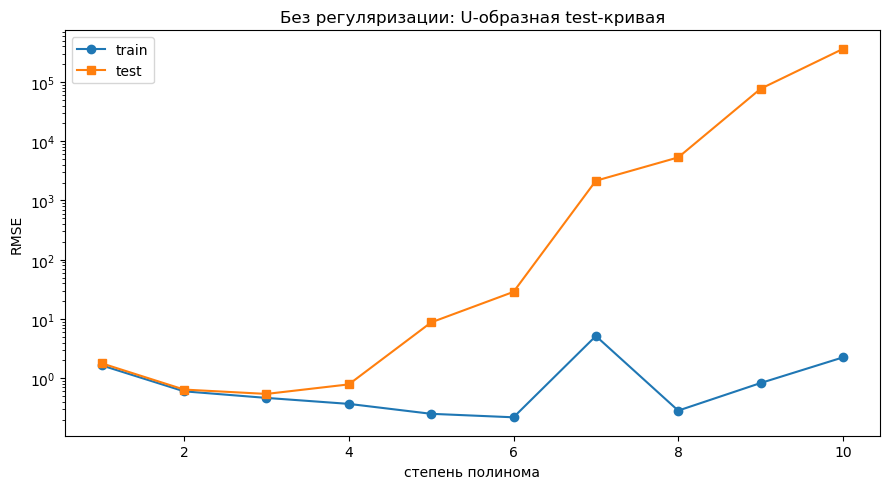

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_overfit['degree'], df_overfit['rmse_train'], 'o-', label='train')
ax.plot(df_overfit['degree'], df_overfit['rmse_test'], 's-', label='test')
ax.set_xlabel('степень полинома')
ax.set_ylabel('RMSE')
ax.set_title('Без регуляризации: U-образная test-кривая')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

На графике видно классическую картину:

- train-RMSE монотонно падает (модель учится всё лучше воспроизводить train).
- test-RMSE сначала падает (полезное усложнение), потом **взрывается** (переобучение).

Регуляризация должна сгладить эту правую часть: разрешить модели быть гибкой, но запретить веса вырасти до абсурдных значений.

---

## Ridge: L2-регуляризация

Ridge добавляет к loss-функции штраф `α · Σwᵢ²`. Идея: «можешь использовать любые фичи, но не давай весам разрастаться до сумасшедших значений». L2 **уменьшает** все веса пропорционально, но никогда не зануляет.

Формула:

$$
Loss_{Ridge} = \frac{1}{n}\sum_i (y_i - \hat y_i)^2 + \alpha \sum_j w_j^2
$$

где:

- $\alpha$ (alpha) — сила регуляризации. 0 = обычный линрег, ∞ = все веса в 0.
- $w_j$ — веса модели.
- Первое слагаемое — обычная MSE.

### Зачем `StandardScaler`

Регуляризация штрафует веса. Если у одной фичи диапазон 0-300 (TV-бюджет), а у другой 0-50 (radio), их веса будут несравнимы — большие фичи получат маленькие веса просто из-за масштаба, и штраф ляжет на них непропорционально. Решение — z-нормализация перед регуляризацией.

**Это обязательно для Ridge/Lasso/ElasticNet.**

In [4]:
# Ручной перебор alpha без CV для иллюстрации.
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []
for a in alphas:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=4, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a)),
    ])
    pipe.fit(X_train, y_train)
    rmse_test = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))
    ridge_results.append({'alpha': a, 'rmse_test': rmse_test})

ridge_df = pd.DataFrame(ridge_results)
ridge_df.round(3)

,alpha,rmse_test
0,0.001,0.647
1,0.010,0.539
2,0.100,0.560
3,1.000,0.725
4,10.000,0.898
5,100.000,1.543
6,1000.000,2.848


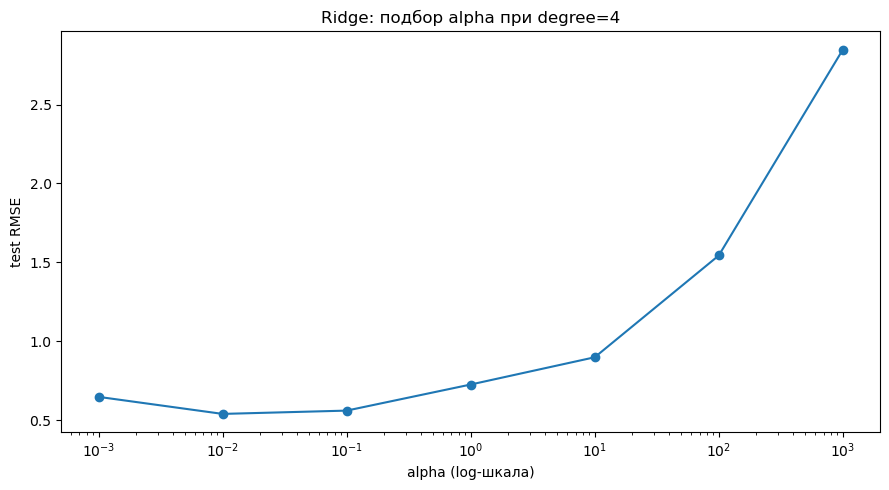

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ridge_df['alpha'], ridge_df['rmse_test'], 'o-')
ax.set_xscale('log')
ax.set_xlabel('alpha (log-шкала)')
ax.set_ylabel('test RMSE')
ax.set_title('Ridge: подбор alpha при degree=4')
plt.tight_layout()
plt.show()

На графике видна U-образная кривая: при `α=0` модель переобучается (большой test RMSE), при огромных `α` модель недообучается (веса задавлены до нуля). Лучшее значение — где-то посередине.

### `RidgeCV` — автоматический подбор alpha

Вместо ручного цикла используем `RidgeCV`, которая делает CV-поиск alpha сама и быстро (есть закрытая формула).

In [6]:
ridge_cv_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)),
])
ridge_cv_pipe.fit(X_train, y_train)

best_alpha = ridge_cv_pipe.named_steps['ridge'].alpha_
rmse_ridge = np.sqrt(mean_squared_error(y_test, ridge_cv_pipe.predict(X_test)))
print(f'Best alpha:  {best_alpha:.4f}')
print(f'Test RMSE:   {rmse_ridge:.3f}')

Best alpha:  0.0013
Test RMSE:   0.620


---

## Lasso: L1-регуляризация

Lasso добавляет штраф `α · Σ|wᵢ|`. Главное отличие от Ridge: L1 **зануляет** веса ненужных фичей. Это даёт автоматический отбор признаков.

$$
Loss_{Lasso} = \frac{1}{n}\sum_i (y_i - \hat y_i)^2 + \alpha \sum_j |w_j|
$$

**Когда нужен:** сотни фичей, многие из них шумовые (генетика, текст, click-stream). Lasso оставит только информативные.

In [7]:
lasso_cv_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(alphas=np.logspace(-3, 1, 50), cv=5, max_iter=20000, random_state=RANDOM_STATE)),
])
lasso_cv_pipe.fit(X_train, y_train)

best_alpha_l = lasso_cv_pipe.named_steps['lasso'].alpha_
lasso_coefs = lasso_cv_pipe.named_steps['lasso'].coef_
rmse_lasso = np.sqrt(mean_squared_error(y_test, lasso_cv_pipe.predict(X_test)))

n_zero = (lasso_coefs == 0).sum()
n_total = len(lasso_coefs)
print(f'Best alpha:        {best_alpha_l:.4f}')
print(f'Test RMSE:         {rmse_lasso:.3f}')
print(f'Занулённых фичей:  {n_zero} из {n_total} ({n_zero/n_total:.0%})')

Best alpha:        0.0037
Test RMSE:         0.509
Занулённых фичей:  21 из 34 (62%)


Lasso занулил часть полиномиальных фичей. Это и есть **feature selection**: среди 34 фичей (полином degree=4 от 3 исходных) Lasso оставил только информативные. В банковских скоринг-моделях обычно начинают именно с Lasso, чтобы из тысяч транзакционных фичей отобрать сотню важных.

---

## ElasticNet: L1 + L2

Гибрид. Параметр `l1_ratio` управляет долей L1: 0 = чистый Ridge, 1 = чистый Lasso. Когда фичи коррелированы, чистый Lasso выбирает случайно одну из них; ElasticNet стабильнее — оставляет группы коррелированных фичей вместе.

In [8]:
en_cv_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler()),
    ('en', ElasticNetCV(
        alphas=np.logspace(-3, 1, 30),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5, max_iter=20000, random_state=RANDOM_STATE,
    )),
])
en_cv_pipe.fit(X_train, y_train)

en = en_cv_pipe.named_steps['en']
rmse_en = np.sqrt(mean_squared_error(y_test, en_cv_pipe.predict(X_test)))
print(f'Best alpha:    {en.alpha_:.4f}')
print(f'Best l1_ratio: {en.l1_ratio_:.2f}')
print(f'Test RMSE:     {rmse_en:.3f}')

Best alpha:    0.0036
Best l1_ratio: 0.90
Test RMSE:     0.524


---

## Сравнение: baseline vs Ridge vs Lasso vs ElasticNet

Сводим все модели в одну таблицу + bar chart.

In [9]:
# Базовая модель без регуляризации (для сравнения).
baseline = make_pipeline(
    PolynomialFeatures(degree=4, include_bias=False),
    LinearRegression(),
)
baseline.fit(X_train, y_train)
rmse_base = np.sqrt(mean_squared_error(y_test, baseline.predict(X_test)))

summary = pd.DataFrame([
    {'model': 'no reg (degree=4)', 'rmse_test': rmse_base},
    {'model': 'Ridge',             'rmse_test': rmse_ridge},
    {'model': 'Lasso',             'rmse_test': rmse_lasso},
    {'model': 'ElasticNet',        'rmse_test': rmse_en},
]).round(3)
summary

,model,rmse_test
0,no reg (degree=4),0.786
1,Ridge,0.620
2,Lasso,0.509
3,ElasticNet,0.524


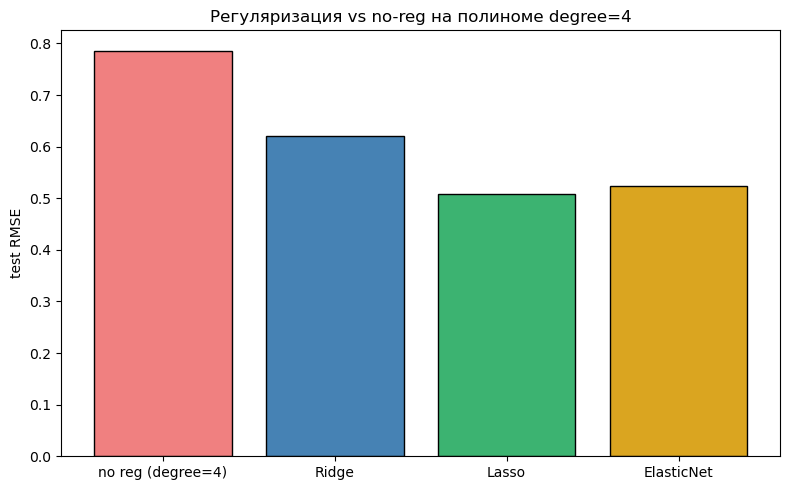

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['lightcoral', 'steelblue', 'mediumseagreen', 'goldenrod']
ax.bar(summary['model'], summary['rmse_test'], color=colors, edgecolor='black')
ax.set_ylabel('test RMSE')
ax.set_title('Регуляризация vs no-reg на полиноме degree=4')
plt.tight_layout()
plt.show()

На графике видно: все три регуляризованные модели лучше «голого» полинома degree=4. Между Ridge / Lasso / ElasticNet разница небольшая — зависит от датасета. На банковских данных с тысячами фичей Lasso/ElasticNet обычно выигрывают за счёт автоматического отбора.

---

## Бонус: `GridSearchCV` для подбора `degree` + `alpha` одновременно

**`GridSearchCV`** (`sklearn.model_selection.GridSearchCV`) — это инструмент sklearn для систематического перебора комбинаций гиперпараметров с кросс-валидацией. Ты передаёшь `param_grid` — словарь `{имя_параметра: [список значений]}`, и для каждой комбинации `GridSearchCV` запускает k-fold CV, считает среднюю метрику и в конце возвращает лучшую комбинацию через `.best_params_` + лучший estimator через `.best_estimator_`.

Зачем нужен. `RidgeCV` подбирает только `alpha` для одной модели Ridge. `GridSearchCV` универсальнее: умеет одновременно перебирать `degree` полинома, `alpha` штрафа, тип scaler'а — что угодно, что выставляется через `set_params`. В `Pipeline` параметры адресуются через двойное подчёркивание: `'ridge__alpha'` означает «параметр `alpha` шага по имени `ridge`». На собесах часто спрашивают «как ты тюнишь модель» — корректный ответ: «`Pipeline` + `GridSearchCV` с `cv=5`, метрика подбирается под бизнес-задачу».

In [11]:
pipe_grid = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge()),
])

param_grid = {
    'poly__degree': [2, 3, 4, 5],
    'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
}

grid = GridSearchCV(
    pipe_grid, param_grid,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print(f'Лучшие параметры: {grid.best_params_}')
print(f'Best CV RMSE:    {-grid.best_score_:.3f}')
print(f'Test RMSE:       {np.sqrt(mean_squared_error(y_test, grid.predict(X_test))):.3f}')

Лучшие параметры: {'poly__degree': 5, 'ridge__alpha': 0.01}
Best CV RMSE:    0.638
Test RMSE:       0.673


---

## Что мы сделали

1. Воспроизвели проблему переобучения на полиноме degree=10 — U-образная test-кривая.
2. Применили Ridge (L2) → `RidgeCV` для автоподбора alpha.
3. Применили Lasso (L1) → автоматический feature selection (зануление коэффициентов).
4. Применили ElasticNet (L1+L2) для устойчивости к мультиколлинеарности.
5. Сравнили 4 модели через bar chart.
6. Использовали `GridSearchCV` для совместного подбора `degree` и `alpha`.

Дальше — `03_regularization_practice.ipynb` (10 упражнений) и `_solution.ipynb`.